In [824]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import random

In [826]:
train_dir = "C:/YvesProject/中央/AI作業/train_resized/"
test_dir = "C:/YvesProject/中央/AI作業/test_resized/"
artists = pd.read_csv("C:/YvesProject/中央/AI作業/artists.csv")
num_classes = artists.shape[0]
print("Number of artists : ", num_classes)
artists.head()

Number of artists :  50


,id,name,years,genre,nationality,bio,wikipedia,paintings
0,0,Amedeo Modigliani,1884 - 1920,Expressionism,Italian,Amedeo Clemente Modigliani (Italian pronunciat...,http://en.wikipedia.org/wiki/Amedeo_Modigliani,193
1,1,Vasiliy Kandinskiy,1866 - 1944,"Expressionism,Abstractionism",Russian,Wassily Wassilyevich Kandinsky (Russian: ?а?и?...,http://en.wikipedia.org/wiki/Wassily_Kandinsky,88
2,2,Diego Rivera,1886 - 1957,"Social Realism,Muralism",Mexican,Diego María de la Concepción Juan Nepomuceno E...,http://en.wikipedia.org/wiki/Diego_Rivera,70
3,3,Claude Monet,1840 - 1926,Impressionism,French,Oscar-Claude Monet (; French: [klod m?n?]; 14 ...,http://en.wikipedia.org/wiki/Claude_Monet,73
4,4,Rene Magritte,1898 - 1967,"Surrealism,Impressionism",Belgian,René François Ghislain Magritte (French: [??ne...,http://en.wikipedia.org/wiki/René_Magritte,194


In [828]:
### 只取出名字與畫的數量，把名字用下底線連起來
artists = artists.loc[:, ["name", "paintings"]]
artists["name"] = artists["name"].str.split(" ").apply(lambda parts: "_".join(parts))
artists.head()

,name,paintings
0,Amedeo_Modigliani,193
1,Vasiliy_Kandinskiy,88
2,Diego_Rivera,70
3,Claude_Monet,73
4,Rene_Magritte,194


可以看到每個畫家之間的畫作數量很不平均，這會影響到模型的訓練。
最多畫作為 :  877  最少畫作為 :  24
畫作數量的平均值為 :  168.92


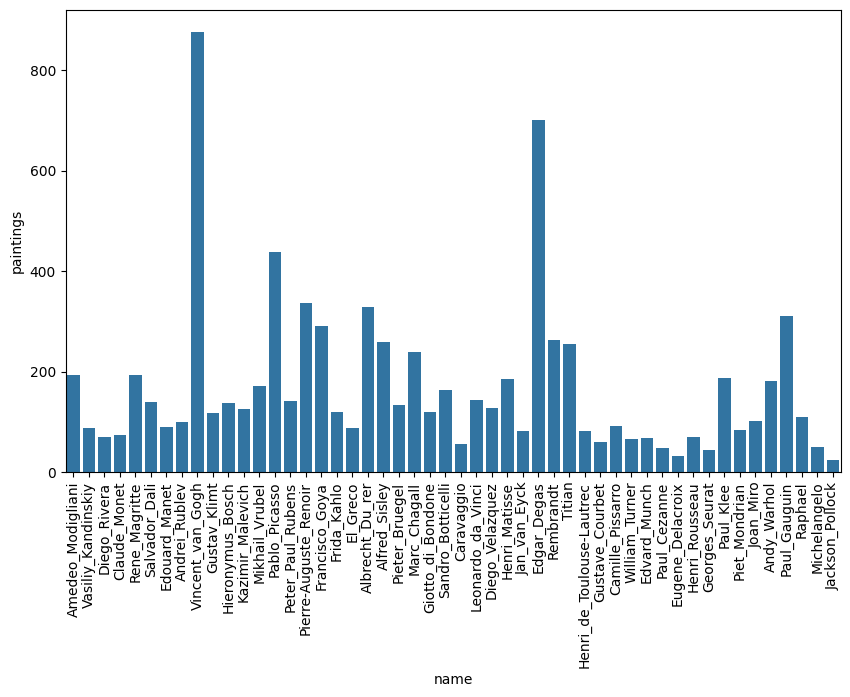

In [830]:
%matplotlib inline
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="name", y="paintings",data=artists)
for item in barplot.get_xticklabels():
    item.set_rotation(90)

avg_paint = artists.paintings.mean()

print("可以看到每個畫家之間的畫作數量很不平均，這會影響到模型的訓練。")
print("最多畫作為 : ", artists.paintings.max(), " 最少畫作為 : ", artists.paintings.min())
print("畫作數量的平均值為 : ", avg_paint)

training 畫作總共畫作有 :  7520


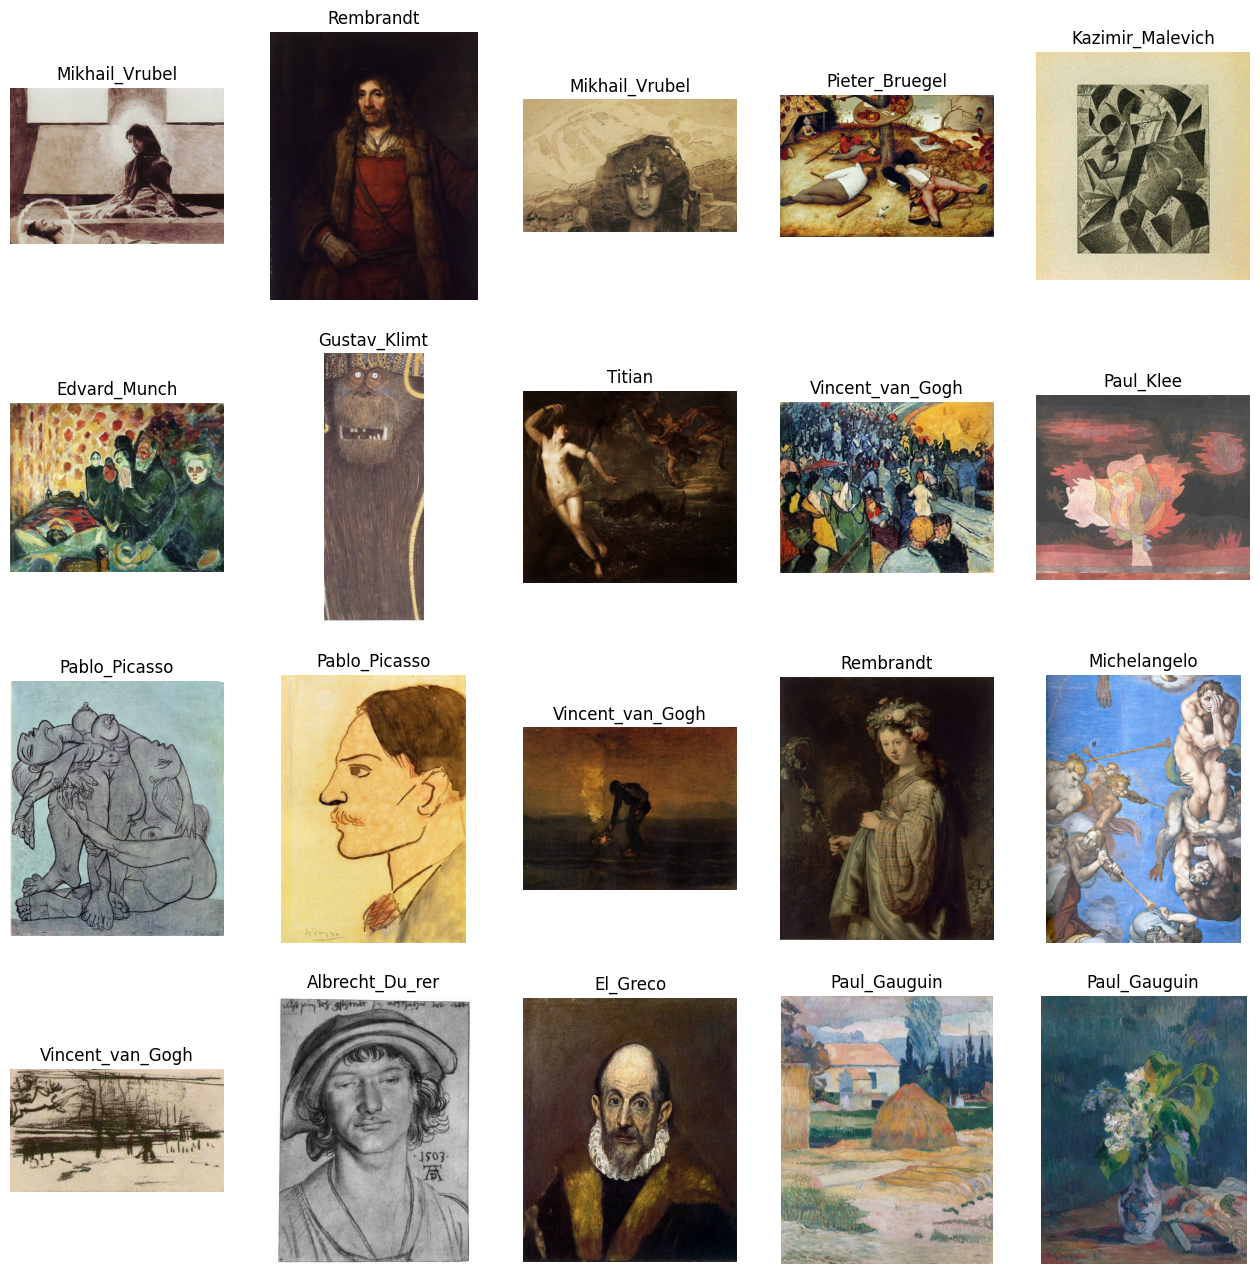

In [831]:
from PIL import Image

img_path = os.path.join(train_dir, imgName)
total_len = len(img_list)
random_list = random.sample(range(0, total_len), 20)
print("training 畫作總共畫作有 : ", total_len)

show_imgs = [img_list[rand] for rand in random_list]

plt.figure(figsize=(16, 16))
for index, imgName in enumerate(show_imgs):
    img_path = os.path.join(train_dir, imgName)

    try:
        img = Image.open(img_path)
        img = np.array(img)  # 將 PIL 圖片轉換為 NumPy 陣列
        img = cv.cvtColor(img, cv.COLOR_RGB2BGR)  # 轉換為 OpenCV 格式
    except Exception as e:
        print(f"無法讀取圖檔 {img_path}，錯誤訊息: {e}")
        continue
        
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.subplot(4, 5, index + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("_".join(imgName.split("_")[:-1]))

In [833]:
# 移除檔名中的 "_數字.jpg" 部分
def remove_number_from_filename(filename):
    return re.sub(r'_\d+\.jpg$', '', filename)

def make_author_dict(train_dir):
    # 取得所有圖片檔案名稱
    img_list = os.listdir(train_dir)
    
    # 使用 remove_number_from_filename 函式處理檔名，去掉數字和檔案後綴
    author_list = sorted(set([remove_number_from_filename(img) for img in img_list]))  # 去掉 _後的數字部分並排序
    author_dict = {author: idx for idx, author in enumerate(author_list)}  # 映射作者名稱到數字
    return author_dict

# 創建作者名稱到數字的映射
class_name = make_author_dict(train_dir)

# 創建數字到作者名稱的反向映射
rev_class_name = {v: k for k, v in class_name.items()}

# 測試
print("作者名稱到數字映射:", class_name)
print("數字到作者名稱映射:", rev_class_name)

作者名稱到數字映射: {'Albrecht_Du_rer': 0, 'Alfred_Sisley': 1, 'Amedeo_Modigliani': 2, 'Andrei_Rublev': 3, 'Andy_Warhol': 4, 'Camille_Pissarro': 5, 'Caravaggio': 6, 'Claude_Monet': 7, 'Diego_Rivera': 8, 'Diego_Velazquez': 9, 'Edgar_Degas': 10, 'Edouard_Manet': 11, 'Edvard_Munch': 12, 'El_Greco': 13, 'Eugene_Delacroix': 14, 'Francisco_Goya': 15, 'Frida_Kahlo': 16, 'Georges_Seurat': 17, 'Giotto_di_Bondone': 18, 'Gustav_Klimt': 19, 'Gustave_Courbet': 20, 'Henri_Matisse': 21, 'Henri_Rousseau': 22, 'Henri_de_Toulouse-Lautrec': 23, 'Hieronymus_Bosch': 24, 'Jackson_Pollock': 25, 'Jan_van_Eyck': 26, 'Joan_Miro': 27, 'Kazimir_Malevich': 28, 'Leonardo_da_Vinci': 29, 'Marc_Chagall': 30, 'Michelangelo': 31, 'Mikhail_Vrubel': 32, 'Pablo_Picasso': 33, 'Paul_Cezanne': 34, 'Paul_Gauguin': 35, 'Paul_Klee': 36, 'Peter_Paul_Rubens': 37, 'Pierre-Auguste_Renoir': 38, 'Piet_Mondrian': 39, 'Pieter_Bruegel': 40, 'Raphael': 41, 'Rembrandt': 42, 'Rene_Magritte': 43, 'Salvador_Dali': 44, 'Sandro_Botticelli': 45, 'Titian'

In [834]:
from tensorflow.keras.layers.experimental import preprocessing

# 定義數據增強
data_augmentation = tf.keras.Sequential([
    preprocessing.RandomFlip("horizontal_and_vertical"),  # 隨機水平和垂直翻轉
    preprocessing.RandomRotation(0.25),                    # 隨機旋轉
    preprocessing.RandomZoom(0.2),                         # 隨機縮放
    preprocessing.RandomTranslation(0.3, 0.2),             # 隨機平移（橫向 30%，縱向 20%）
    preprocessing.RandomContrast(0.2),                     # 隨機對比度變化
])

# 取得圖像標籤並轉成數字
def get_label(pic_name, class_name):
    # 取得作者名稱（去掉數字和後綴）
    author_name = remove_number_from_filename(pic_name)
    
    # 將作者名稱轉換為對應的數字標籤
    label = class_name.get(author_name, -1)  # 若找不到作者，返回 -1 (表示錯誤)
    
    return label

# 合併路徑
def get_path(dir, pic_name):
    return os.path.join(dir, pic_name)

# 生成圖片路徑和標籤
def make_paths_label(dir, class_name):
    img_list = os.listdir(dir)
    paths = []
    labels = []

    # 遍歷所有圖片檔案
    for img_name in img_list:
        # 取得圖片的完整路徑
        path = get_path(dir, img_name)
        paths.append(path)
        
        # 取得對應的標籤（數字）
        label = get_label(img_name, class_name)
        labels.append(label)

    # 將 labels 轉換為 one-hot 編碼
    onehot_labels = np.zeros((len(labels), len(class_name)))
    for idx, label in enumerate(labels):
        if label != -1:
            onehot_labels[idx, label] = 1  # 將對應的索引設為 1

    return paths, onehot_labels

def create_dataset_from_raw(paths, labels, img_size=(256, 256), batch_size=32, augment=False, class_counts=None):
    dataset = tf.data.Dataset.from_tensor_slices((list(paths), np.array(labels)))

    def map_fn(x, y):
        img = tf.io.read_file(x)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        tmp_file_name = tf.strings.split(x, sep='/')  # 分割路徑
        tmp_file_name = tmp_file_name[-1]  # 取得檔案名稱
        tmp_file_name = tf.strings.regex_replace(tmp_file_name, ' ', '_')  # 將檔名的空格替換為下劃線
        tmp_paint_count = artists.loc[artists['name'] == tmp_file_name, 'paintings'].values  # 該畫家擁有的作品數量
        if augment and tmp_paint_count < avg_paint:
            img = data_augmentation(img)  # 只對少數樣本的畫家進行增強
        img = img / 255.0
        return img, y

    # 使用 map 處理圖片
    dataset = dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    # 打散資料
    dataset = dataset.batch(batch_size)
    # 預取資料以加速訓練
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# 創建資料集
dataset = create_dataset(train_dir, class_name, augment=True)

# 測試資料集
for images, labels in dataset.take(1):  # 取得一個批次的資料
    print(images.shape)  # (batch_size, 256, 256, 3)
    print(labels.shape)  # (batch_size, 50)

(32, 256, 256, 3)
(32, 50)


In [835]:
# 設定圖片大小和打散緩衝區大小
IMG_WIDTH = 1024  # 設定圖片寬度
IMG_HEIGHT = 1024  # 設定圖片高度
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)  # 圖片大小
SHUFFLE_BUFFER = 1000  # 設定打散緩衝區大小
BATCH_SIZE = 32  # 設定批次大小
MODEL_WIDTH = 256  # 設定模型採用的寬度
MODEL_HEIGHT = 256  # 設定模型採用的高度

# Step 1: 拿到所有路徑和標籤
paths, labels = make_paths_label(train_dir, class_name)

# Step 2: 打散
combined = list(zip(paths, labels))
random.shuffle(combined)
paths, labels = zip(*combined)

# Step 3: 分割
split_index = int(0.8 * len(paths))
train_paths, val_paths = paths[:split_index], paths[split_index:]
train_labels, val_labels = labels[:split_index], labels[split_index:]

# Step 4: 分別創建資料集
train_ds = create_dataset_from_raw(train_paths, train_labels, img_size=(MODEL_WIDTH, MODEL_HEIGHT), augment=True)
val_ds = create_dataset_from_raw(val_paths, val_labels, img_size=(MODEL_WIDTH, MODEL_HEIGHT), augment=False)

# 如果需要，這裡可以進一步增加預取功能來加速訓練
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# 查看資料集中的部分資料
for image, label in train_ds.take(1):  # 查看一個訓練集的批次
    print(f"Image shape: {image.shape}, Label shape: {label.shape}")

Image shape: (32, 256, 256, 3), Label shape: (32, 50)


In [840]:
###4. 建立模型
input_shape = (MODEL_WIDTH, MODEL_HEIGHT, 3)

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_84"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_139 (Conv2D)         (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d_139 (MaxPooli  (None, 128, 128, 32)     0         
 ng2D)                                                           
                                                                 
 dropout_170 (Dropout)       (None, 128, 128, 32)      0         
                                                                 
 conv2d_140 (Conv2D)         (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_140 (MaxPooli  (None, 64, 64, 64)       0         
 ng2D)                                                           
                                                                 
 dropout_171 (Dropout)       (None, 64, 64, 64)      

In [858]:
###5. 制定訓練計畫
EPOCHS = 30
opti = tf.keras.optimizers.RMSprop(momentum=0.1) 
best_acc_path = "C:/YvesProject/中央/AI作業/best_accuracy.txt"
model_save_path = "C:/YvesProject/中央/AI作業/best_model.h5"

#model = tf.keras.models.load_model(model_path)

model.compile(
    optimizer=opti,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds)

Epoch 1/30
188/188 [==============================] - 7s 33ms/step - loss: 1.2021 - accuracy: 0.7030 - val_loss: 4.5980 - val_accuracy: 0.3597
Epoch 2/30
188/188 [==============================] - 6s 32ms/step - loss: 1.1296 - accuracy: 0.7244 - val_loss: 3.3125 - val_accuracy: 0.3737
Epoch 3/30
188/188 [==============================] - 7s 35ms/step - loss: 1.1090 - accuracy: 0.7312 - val_loss: 4.4004 - val_accuracy: 0.3384
Epoch 4/30
188/188 [==============================] - 6s 32ms/step - loss: 1.1441 - accuracy: 0.7171 - val_loss: 3.4889 - val_accuracy: 0.3710
Epoch 5/30
188/188 [==============================] - 6s 32ms/step - loss: 1.1015 - accuracy: 0.7359 - val_loss: 3.8545 - val_accuracy: 0.3617
Epoch 6/30
188/188 [==============================] - 6s 34ms/step - loss: 1.1087 - accuracy: 0.7264 - val_loss: 3.5521 - val_accuracy: 0.3670
Epoch 7/30
188/188 [==============================] - 6s 34ms/step - loss: 1.1031 - accuracy: 0.7329 - val_loss: 3.3278 - val_accuracy: 0.3524

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


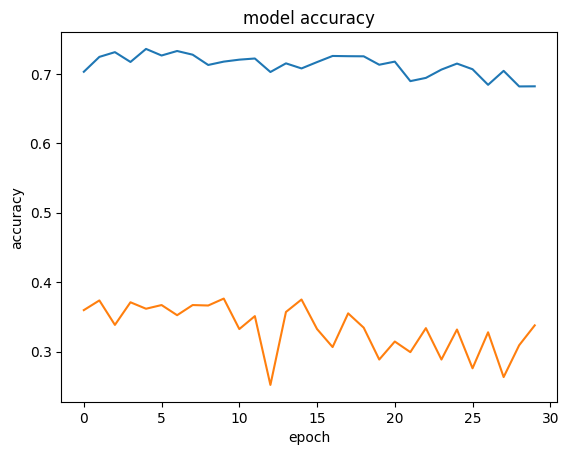

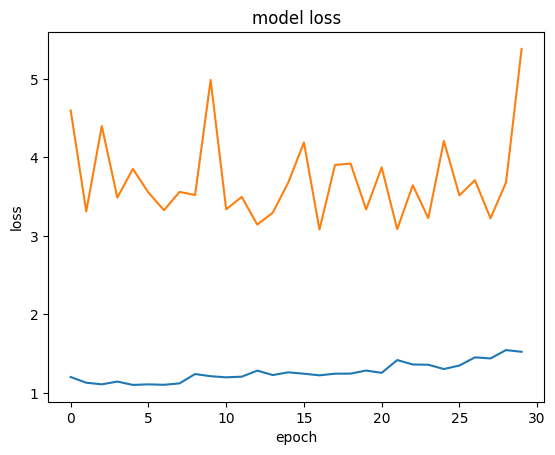

In [859]:
print(history.history.keys())

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")

plt.show()

In [860]:
# 讀取歷史最佳準確率
if os.path.exists(best_acc_path):
    with open(best_acc_path, "r") as f:
        best_accuracy = float(f.read().strip())
else:
    best_accuracy = 0.0  # 如果沒檔案，就視為初次訓練

# 讀入測試資料並評估模型
test_ds = create_dataset(test_dir, class_name)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# 評估測試集
score = model.evaluate(test_ds)
test_loss, test_acc = score[0], score[1]

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 如果目前準確率比歷史準確率還高，就儲存
if test_acc > best_accuracy:
    print(f"✅ New best accuracy ({test_acc:.4f}) > old ({best_accuracy:.4f}) → Saving model!")
    model.save(model_save_path)
    with open(best_acc_path, "w") as f:
        f.write(str(test_acc))
else:
    print(f"⚠️ Test accuracy ({test_acc:.4f}) did not improve from best ({best_accuracy:.4f}). Model not saved.")

27/27 [==============================] - 1s 17ms/step - loss: 5.2453 - accuracy: 0.3413
Test loss: 5.245254993438721
Test accuracy: 0.341317355632782
⚠️ Test accuracy (0.3413) did not improve from best (0.3892). Model not saved.


In [845]:
# 7. 做預測
def predict_author(img):
    """
    input : opencv img (height, width, 3)
    output : 作家名字，例如 'Claude_Monet'
    """

    # Step 1: Resize 到模型輸入大小 (256, 256)
    img_resized = cv.resize(img, (256, 256))

    # Step 2: 正規化
    img_resized = img_resized / 255.0

    # Step 3: 增加 batch 維度 (1, 256, 256, 3)
    img_input = np.expand_dims(img_resized, axis=0)

    # Step 4: 丟入模型預測
    pred = model.predict(img_input, verbose=0)

    # Step 5: 取最大機率的索引
    pred_index = np.argmax(pred, axis=1)[0]

    # Step 6: 從 index 轉換成作者名稱
    author_name = rev_class_name[pred_index]

    return author_name


Text(0.5, 1.0, 'True Author : Paul_Gauguin \nPred Author : Pablo_Picasso')

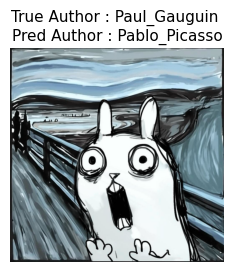

In [846]:
plt.figure(figsize=(16, 16))
test_path = "C:/YvesProject/中央/AI作業/036163c2-cedc-4f8c-ac9d-4df87d187706.jpg"
img = Image.open(test_path)
img = np.array(img)  # 將 PIL 圖片轉換為 NumPy 陣列
img = cv.cvtColor(img, cv.COLOR_RGB2BGR)  # 轉換為 OpenCV 格式

plt.subplot(4, 5, index + 1)
plt.imshow(img)
plt.axis("off")
plt.title(
    "True Author : {} \nPred Author : {}".format("_".join(imgName.split("_")[:-1]), predict_author(img)),
    size=11,
)